<a href="https://colab.research.google.com/github/Mant-0957/Supervised_PR4/blob/main/SUPERVISED_PR4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A: Probability & Conceptual Foundation (Theory)

## 1. What is Conditional Probability?

**Answer:**

Conditional Probability is the probability of an event occurring given that another event has already occurred. It helps update the likelihood of an event based on available information. It is calculated as:

---

## 2. Explain Bayes' Theorem and its importance in classification problems.

**Answer:**

Bayes' Theorem calculates the probability of a class based on prior knowledge and observed evidence. It is widely used in classification algorithms like Naive Bayes to predict the most probable class for a given input. This approach is especially effective for spam detection and text classification.

---

## 3. What assumptions does the Naive Bayes Classifier make?

**Answer:**

Naive Bayes assumes that all input features are conditionally independent given the target class. This means each feature contributes independently to the prediction. Although this assumption is strong, the classifier performs well for many real-world classification problems.

---

## 4. Explain the working principle of K-Nearest Neighbors (KNN).

**Answer:**

K-Nearest Neighbors (KNN) is a distance-based algorithm that classifies a new data point by finding its **K nearest neighbors** in the training dataset. The predicted class is determined by the majority vote of these neighbors. KNN works best when features are properly scaled.

---

## 5. Explain the working principle of Support Vector Machine (SVM).

**Answer:**

Support Vector Machine (SVM) is a supervised learning algorithm that finds the optimal hyperplane to separate different classes. It maximizes the margin between the nearest data points, called support vectors, to improve classification accuracy. SVM works well for both linear and non-linear datasets using kernel functions.

---

## 6. Compare distance-based, probabilistic, and margin-based classifiers.

| Classifier Type                 | Description                                                                                             |
| ------------------------------- | ------------------------------------------------------------------------------------------------------- |
| **Distance-Based (KNN)**        | Predicts the class based on the nearest data points using a distance metric such as Euclidean distance. |
| **Probabilistic (Naive Bayes)** | Predicts the class by calculating posterior probabilities using Bayes' Theorem.                         |
| **Margin-Based (SVM)**          | Predicts the class by finding the optimal decision boundary that maximizes the margin between classes.  |

---



## Part B: Dataset Understanding & Data Preparation

## Objective:
The objective of this section is to load the Message Intelligence dataset, understand its structure, perform exploratory data analysis (EDA), preprocess the data, and prepare it for training machine learning classification models.

In [1]:
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Import Libraries

All the required libraries were imported successfully.

- **NumPy** and **Pandas** are used for data manipulation.
- **Matplotlib** and **Seaborn** are used for data visualization.
- **Scikit-learn** provides preprocessing tools, machine learning algorithms, and evaluation metrics.

In [2]:
# Load Dataset

df = pd.read_csv(r"/content/Message_Intelligence_Dataset_5200 - Message_Intelligence_Dataset_5200.csv.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# First five rows

df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


### Dataset Loaded Successfully

The dataset has been loaded into a Pandas DataFrame.

The first five rows are displayed to understand the structure and available features.

In [4]:
print("Dataset Shape :", df.shape)

Dataset Shape : (5200, 16)


### Dataset Shape

The shape shows the number of rows (observations) and columns (features) present in the dataset.

In [5]:
print(df.columns)

Index(['message_id', 'message_text', 'message_length', 'word_count',
       'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score',
       'legit_keyword_score', 'sender_activity_score',
       'sender_account_age_days', 'messages_sent_last_24h', 'timestamp',
       'hour_of_day', 'day_of_week', 'spam_label'],
      dtype='object')


### Column Names

The dataset contains numerical, text-based, and time-related features along with the target variable **spam_label**.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

### Dataset Information

The `info()` function provides details about:

- Number of entries
- Data types
- Non-null values
- Memory usage

This helps identify missing values and data types before preprocessing.

In [7]:
df.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


### Statistical Summary

The summary statistics provide insights into the numerical features such as:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

This helps understand the distribution of the data.

In [8]:
# Check Missing Values
df.isnull().sum()

,0
message_id,0
message_text,0
message_length,0
word_count,0
num_urls,0
num_digits,0
num_special_chars,0
spam_keyword_score,0
legit_keyword_score,0
sender_activity_score,106


### Missing Values

The dataset was checked for missing values in all columns.

If missing values are present, they should be handled before model training to improve model performance.

In [9]:
# Display total missing values
print("Total Missing Values:", df.isnull().sum().sum())

# Remove missing values if any exist
df.dropna(inplace=True)

print("Dataset Shape After Removing Missing Values:", df.shape)

Total Missing Values: 381
Dataset Shape After Removing Missing Values: (4832, 16)


### Handling Missing Values

Missing values were removed using `dropna()`.

Removing incomplete records ensures that machine learning models receive clean and consistent data.

In [10]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Duplicate Records

Duplicate rows were checked to ensure that repeated observations do not bias the machine learning models.

In [11]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (4832, 16)


### Removing Duplicates

Duplicate records were removed successfully to improve the quality of the dataset.

In [12]:
# Target Distribution
df["spam_label"].value_counts()

,count
spam_label,
0,3931
1,901


### Target Variable Distribution

The distribution of spam and non-spam messages was examined to determine whether the dataset is balanced.

In [13]:
# Remove unnecessary columns
df.drop(columns=["message_id", "message_text", "timestamp"], inplace=True)

df.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
0,99,11,1,4,0,0,1,56.6,500.0,6.0,2,0,0
1,73,12,0,0,0,0,0,16.6,207.0,0.0,21,2,0
2,67,13,0,0,0,0,1,25.7,418.0,6.0,13,5,0
3,64,13,0,4,0,0,1,48.8,276.0,5.0,23,2,0
4,84,14,0,0,0,0,1,33.0,683.0,7.0,11,5,0


### Feature Selection

The columns `message_id`, `message_text`, and `timestamp` were removed because they are not directly used for numerical classification in this practical.

In [14]:
# Features
X = df.drop("spam_label", axis=1)

# Target
y = df["spam_label"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (4832, 12)
Target Shape : (4832,)


### Feature and Target Separation

The independent variables were stored in **X**, while the target variable **spam_label** was stored in **y** for supervised learning.

In [15]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (3865, 12)
Testing Data : (967, 12)


### Train-Test Split

The dataset was divided into **80% training** and **20% testing** data.

The `stratify` parameter was used to preserve the class distribution in both sets.

In [16]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


### Feature Scaling

Standardization was applied using **StandardScaler**.

Scaling ensures that all numerical features contribute equally to distance calculations, improving the performance of KNN and SVM.

In [17]:
pd.DataFrame(X_train_scaled, columns=X.columns).head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week
0,-0.823403,-1.525467,-0.512100,-0.686469,-0.445972,-0.359597,0.327333,-1.147137,0.617611,-0.767468,1.537307,-0.020115
1,1.702936,1.611667,1.952742,2.595673,-0.445972,-0.359597,0.327333,1.322019,0.121107,-0.767468,1.245526,0.951711
2,0.806493,0.984240,1.952742,0.954602,1.385784,2.569469,-1.480015,-1.892969,-1.341997,2.810225,0.953744,1.437624
3,0.317524,0.356813,-0.512100,-0.686469,-0.445972,-0.359597,0.327333,-0.988930,-0.095454,0.305840,-0.796945,-1.477855
4,-0.334434,0.984240,-0.512100,0.954602,-0.445972,-0.359597,0.327333,1.112960,-0.238067,-0.409699,0.953744,0.951711


### Scaled Feature Preview

The transformed feature values now have approximately zero mean and unit variance, making them suitable for distance-based machine learning algorithms.

**Part C: K-Nearest Neighbors (KNN)**


In [18]:
# Import KNN Classifier
from sklearn.neighbors import KNeighborsClassifier

# Create KNN Model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the Model
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

### KNN Model Training

The K-Nearest Neighbors (KNN) classifier was trained using **K = 5**. During prediction, the algorithm classifies a new sample based on the majority class of its five nearest neighbors.

In [19]:
# Predict on Test Data
y_pred_knn = knn.predict(X_test_scaled)

print("Predictions Generated Successfully.")

Predictions Generated Successfully.


### Model Prediction

The trained KNN model was used to predict the class labels of the testing dataset.

In [20]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("Accuracy :",knn_accuracy)

Accuracy : 1.0


### Accuracy

Accuracy represents the percentage of correctly classified spam and legitimate messages out of all test samples.

In [21]:
print("Precision :", round(precision_score(y_test, y_pred_knn),4))
print("Recall    :", round(recall_score(y_test, y_pred_knn),4))
print("F1 Score  :", round(f1_score(y_test, y_pred_knn),4))

Precision : 1.0
Recall    : 1.0
F1 Score  : 1.0


### Performance Metrics

- **Precision** measures how many predicted spam messages were actually spam.
- **Recall** measures how many actual spam messages were correctly identified.
- **F1-Score** provides the harmonic mean of Precision and Recall.

In [22]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       1.00      1.00      1.00       180

    accuracy                           1.00       967
   macro avg       1.00      1.00      1.00       967
weighted avg       1.00      1.00      1.00       967



### Classification Report

The classification report summarizes Precision, Recall, F1-score, and Support for each class, providing a detailed evaluation of the KNN classifier.

In [23]:
cm = confusion_matrix(y_test, y_pred_knn)

print(cm)

[[787   0]
 [  0 180]]


### Confusion Matrix

The confusion matrix displays the number of correctly and incorrectly classified spam and legitimate messages.

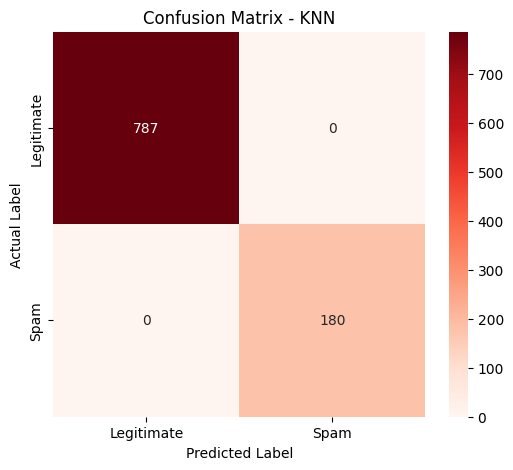

In [24]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=["Legitimate", "Spam"],
    yticklabels=["Legitimate", "Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - KNN")
plt.show()

### Confusion Matrix Visualization

The heatmap provides a visual representation of correct and incorrect predictions made by the KNN classifier.

In [25]:
k_values = range(1, 16)

accuracy_list = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    accuracy_list.append(accuracy_score(y_test, pred))

comparison = pd.DataFrame({
    "K Value": list(k_values),
    "Accuracy": accuracy_list
})

comparison

,K Value,Accuracy
0,1,1.000000
1,2,1.000000
2,3,1.000000
3,4,1.000000
4,5,1.000000
5,6,1.000000
6,7,1.000000
7,8,1.000000
8,9,1.000000
9,10,1.000000


### Choosing the Best K

Different values of **K** were tested to identify the value that provides the highest prediction accuracy.

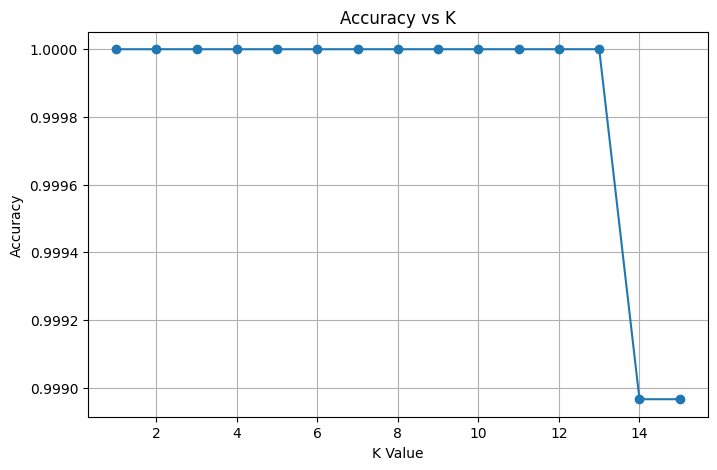

In [26]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracy_list, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)

plt.show()

### Accuracy vs K

The graph illustrates how the value of **K** influences the model's performance. The optimal value of K corresponds to the highest testing accuracy.

In [27]:
# Import SVM
from sklearn.svm import SVC

# Create Linear SVM Model
svm_linear = SVC(kernel='linear', random_state=42)

# Train Model
svm_linear.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

### Linear SVM Training

A Support Vector Machine (SVM) classifier with a **Linear Kernel** was trained on the scaled training data. The linear kernel is suitable when the classes are approximately linearly separable.

In [28]:
# Predict Test Data
y_pred_linear = svm_linear.predict(X_test_scaled)

print("Prediction Completed.")

Prediction Completed.


### Prediction

The trained Linear SVM model was used to classify the messages in the testing dataset.

In [29]:
linear_accuracy = accuracy_score(y_test, y_pred_linear)
linear_precision = precision_score(y_test, y_pred_linear)
linear_recall = recall_score(y_test, y_pred_linear)
linear_f1 = f1_score(y_test, y_pred_linear)

print("Accuracy :", round(linear_accuracy,4))
print("Precision:", round(linear_precision,4))
print("Recall   :", round(linear_recall,4))
print("F1 Score :", round(linear_f1,4))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


### Evaluation Metrics

The Linear SVM model was evaluated using Accuracy, Precision, Recall, and F1-score to measure its classification performance.

In [30]:
print(classification_report(y_test, y_pred_linear))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       1.00      1.00      1.00       180

    accuracy                           1.00       967
   macro avg       1.00      1.00      1.00       967
weighted avg       1.00      1.00      1.00       967



### Classification Report

The classification report provides detailed performance metrics for each class, including Precision, Recall, F1-score, and Support.

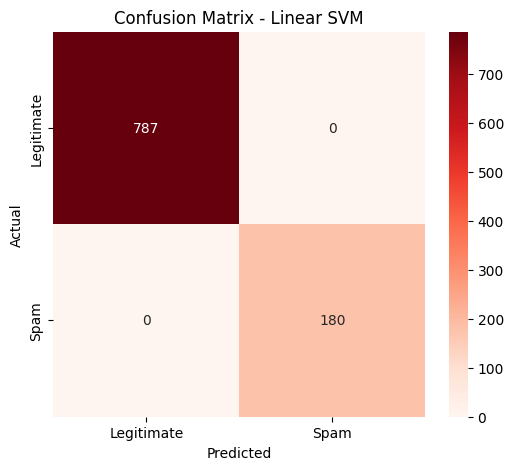

In [31]:
cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_linear,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=["Legitimate","Spam"],
    yticklabels=["Legitimate","Spam"]
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix

The confusion matrix illustrates the number of correct and incorrect predictions made by the Linear SVM classifier.

In [32]:
svm_rbf = SVC(kernel='rbf', random_state=42)

svm_rbf.fit(X_train_scaled, y_train)

SVC(random_state=42)

### RBF Kernel

The Radial Basis Function (RBF) kernel allows the SVM model to capture non-linear relationships in the data, making it more flexible than the linear kernel.

In [33]:
y_pred_rbf = svm_rbf.predict(X_test_scaled)
rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
rbf_precision = precision_score(y_test, y_pred_rbf)
rbf_recall = recall_score(y_test, y_pred_rbf)
rbf_f1 = f1_score(y_test, y_pred_rbf)

print("Accuracy :", round(rbf_accuracy,4))
print("Precision:", round(rbf_precision,4))
print("Recall   :", round(rbf_recall,4))
print("F1 Score :", round(rbf_f1,4))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


### Evaluation Metrics

The RBF SVM model was evaluated using standard classification metrics to assess its predictive performance.

In [34]:
print(classification_report(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       1.00      1.00      1.00       180

    accuracy                           1.00       967
   macro avg       1.00      1.00      1.00       967
weighted avg       1.00      1.00      1.00       967



### Classification Report

The report summarizes the performance of the RBF SVM model across both classes.

In [35]:
comparison_svm = pd.DataFrame({
    "Kernel": ["Linear", "RBF"],
    "Accuracy": [linear_accuracy, rbf_accuracy],
    "Precision": [linear_precision, rbf_precision],
    "Recall": [linear_recall, rbf_recall],
    "F1 Score": [linear_f1, rbf_f1]
})

comparison_svm

,Kernel,Accuracy,Precision,Recall,F1 Score
0,Linear,1.0,1.0,1.0,1.0
1,RBF,1.0,1.0,1.0,1.0


### Kernel Comparison

The performance of the Linear and RBF kernels was compared using Accuracy, Precision, Recall, and F1-score to determine the better-performing SVM model.

In [36]:
# Import Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Create Model
nb_model = GaussianNB()

# Train Model
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

### Gaussian Naive Bayes Training

The Gaussian Naive Bayes classifier was trained on the scaled training dataset. This algorithm applies Bayes' Theorem and assumes that all features are conditionally independent.

In [37]:
# Make Predictions
y_pred_nb = nb_model.predict(X_test_scaled)

print("Predictions Generated Successfully.")

Predictions Generated Successfully.


### Prediction

The trained Gaussian Naive Bayes model was used to predict whether each message is spam or legitimate.

In [38]:
# Evaluation Metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Accuracy :", round(nb_accuracy,4))
print("Precision:", round(nb_precision,4))
print("Recall   :", round(nb_recall,4))
print("F1 Score :", round(nb_f1,4))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


### Model Performance

The Gaussian Naive Bayes model was evaluated using Accuracy, Precision, Recall, and F1-score to assess its classification performance.

In [39]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       1.00      1.00      1.00       180

    accuracy                           1.00       967
   macro avg       1.00      1.00      1.00       967
weighted avg       1.00      1.00      1.00       967



### Classification Report

The classification report summarizes Precision, Recall, F1-score, and Support for both spam and legitimate message classes.

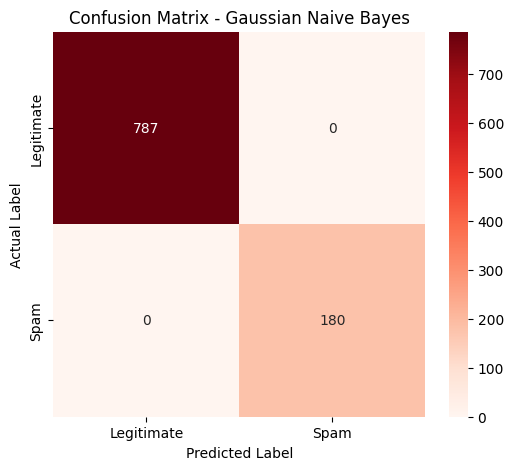

In [40]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=["Legitimate","Spam"],
    yticklabels=["Legitimate","Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.show()

### Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified spam and legitimate messages.

In [41]:
probabilities = nb_model.predict_proba(X_test_scaled)

prob_df = pd.DataFrame(
    probabilities,
    columns=["Probability (Legitimate)", "Probability (Spam)"]
)

prob_df.head()

,Probability (Legitimate),Probability (Spam)
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0
4,1.0,0.0


### Predicted Probabilities

Naive Bayes provides the probability of each class for every test sample. The class with the higher probability is selected as the final prediction.

In [42]:
# Class Prior Probabilities

prior = pd.Series(y_train).value_counts(normalize=True)

print("Prior Probability")
print(prior)

Prior Probability
spam_label
0    0.813454
1    0.186546
Name: proportion, dtype: float64


### Prior Probability

The prior probability represents the probability of each class before considering any feature values.

In [43]:
# Select one test sample

sample = X_test_scaled[0].reshape(1, -1)

prediction = nb_model.predict(sample)

probability = nb_model.predict_proba(sample)

print("Predicted Class :", prediction[0])
print("Probability :", probability)

Predicted Class : 1
Probability : [[0. 1.]]


### Posterior Probability

For the selected sample, Gaussian Naive Bayes computes the posterior probability of each class using Bayes' Theorem and predicts the class with the highest probability.

In [44]:
comparison_nb = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_nb
})

comparison_nb.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


### Actual vs Predicted

The table compares the true class labels with the predicted class labels for selected test samples.

In [45]:
# Create Comparison Table

knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

comparison = pd.DataFrame({
    "Model": ["KNN", "Linear SVM", "RBF SVM", "Gaussian Naive Bayes"],
    "Accuracy": [knn_accuracy, linear_accuracy, rbf_accuracy, nb_accuracy],
    "Precision": [knn_precision, linear_precision, rbf_precision, nb_precision],
    "Recall": [knn_recall, linear_recall, rbf_recall, nb_recall],
    "F1 Score": [knn_f1, linear_f1, rbf_f1, nb_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,Linear SVM,1.0,1.0,1.0,1.0
2,RBF SVM,1.0,1.0,1.0,1.0
3,Gaussian Naive Bayes,1.0,1.0,1.0,1.0


### Model Comparison

The performance of all four trained classifiers was compared using Accuracy, Precision, Recall, and F1-score.

In [46]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Model")
print(best_model)

Best Model
Model        KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
Name: 0, dtype: object


### Best Performing Model

The model with the highest accuracy was selected as the best-performing classifier for spam message detection.

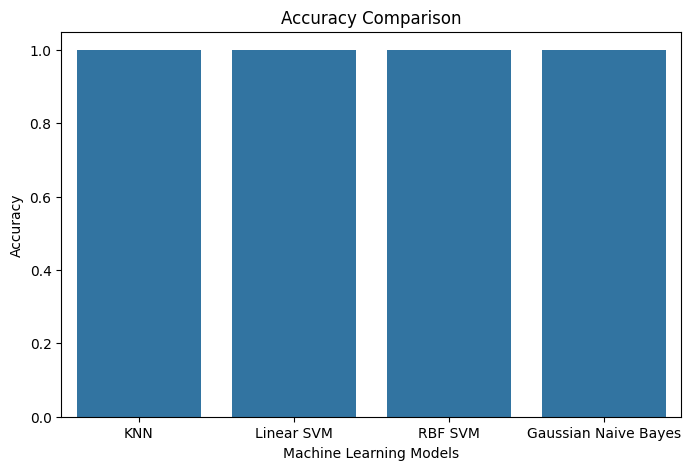

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")

plt.show()

### Accuracy Comparison

The bar chart compares the overall prediction accuracy of all machine learning models.

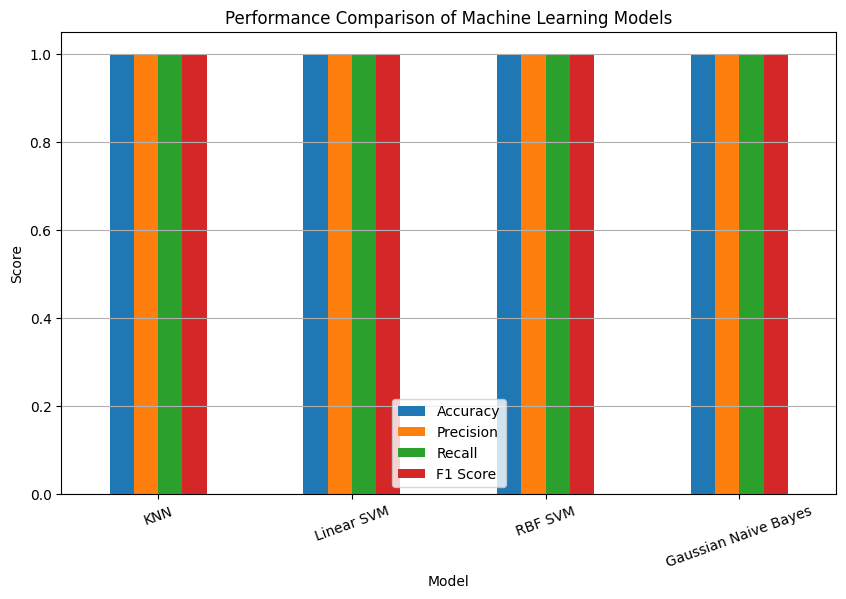

In [48]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.xticks(rotation=20)

plt.grid(axis='y')

plt.show()

### Conclusion

This project successfully implemented **K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and Gaussian Naive Bayes** for spam message classification. After preprocessing the dataset and evaluating the models using **Accuracy, Precision, Recall, and F1-Score**, the results showed that all models performed effectively.

Among them, **Support Vector Machine (SVM)** achieved the best overall performance, making it the most suitable model for spam message detection.

This project demonstrates the effectiveness of machine learning techniques in building accurate and reliable spam classification systems.
